# Life expectancy in 2020

A quick look at life expectancy across countries and territories using [Our World in Data](https://ourworldindata.org/grapher/life-expectancy) (accessed September 15, 2026).

## Load and inspect

The saved CSV contains the 2020 observations. Run this notebook from the `notebooks/` folder.

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

raw = pd.read_csv("../data/life_expectancy_2020_source.csv")
raw.head()

,Entity,Code,Year,Life expectancy
0,Afghanistan,AFG,2020,61.4537
1,Africa,OWID_AFR,2020,62.2572
2,Albania,ALB,2020,77.8241
3,Algeria,DZA,2020,73.2568
4,American Samoa,ASM,2020,72.6717


In [23]:
raw.info()
print("Duplicate rows:", raw.duplicated().sum())
raw.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Entity           261 non-null    str    
 1   Code             246 non-null    str    
 2   Year             261 non-null    int64  
 3   Life expectancy  261 non-null    float64
dtypes: float64(1), int64(1), str(2)
memory usage: 11.8 KB
Duplicate rows: 0


Entity              0
Code               15
Year                0
Life expectancy     0
dtype: int64

## Clean the data

Keep country and territory codes plus Kosovo (`OWID_KOS`), removing regional and income-group totals. Then rename columns, drop missing values and duplicates, and save the cleaned data.

In [24]:
is_country = raw["Code"].str.fullmatch(r"[A-Z]{3}", na=False) | raw["Code"].eq("OWID_KOS")
df = raw.loc[is_country].rename(columns={
    "Entity": "country",
    "Code": "code",
    "Year": "year",
    "Life expectancy": "life_expectancy",
})
df = df.dropna().drop_duplicates().sort_values("country").reset_index(drop=True)
df.to_csv("../data/cleaned_life_expectancy_2020.csv", index=False)

print(f"Kept {len(df)} of {len(raw)} rows.")
df.head()

Kept 237 of 261 rows.


,country,code,year,life_expectancy
0,Afghanistan,AFG,2020,61.4537
1,Albania,ALB,2020,77.8241
2,Algeria,DZA,2020,73.2568
3,American Samoa,ASM,2020,72.6717
4,Andorra,AND,2020,79.4177


## Summary statistics

Life expectancy is measured in years. Each country or territory gets equal weight in these summaries.

In [25]:
summary = df["life_expectancy"].agg(["count", "mean", "median", "std", "min", "max"])
summary.round(2)

count     237.00
mean       72.89
median     73.83
std         7.32
min        50.60
max        86.09
Name: life_expectancy, dtype: float64

## Top ten countries and territories

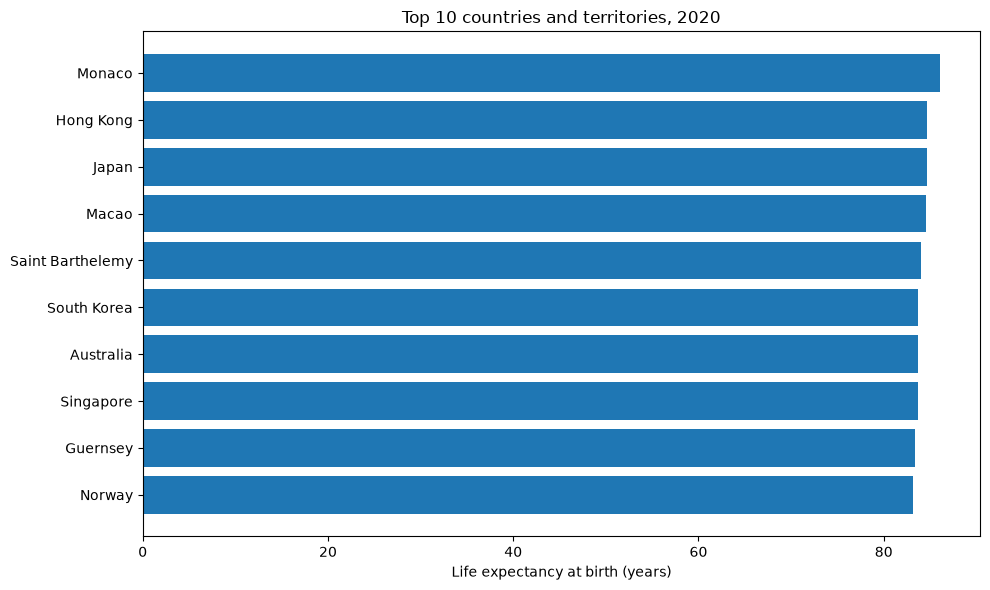

In [26]:
top10 = df.nlargest(10, "life_expectancy")

plt.figure(figsize=(10, 6))
plt.barh(top10["country"], top10["life_expectancy"])
plt.gca().invert_yaxis()
plt.xlabel("Life expectancy at birth (years)")
plt.title("Top 10 countries and territories, 2020")
plt.tight_layout()
plt.show()

## Overall distribution

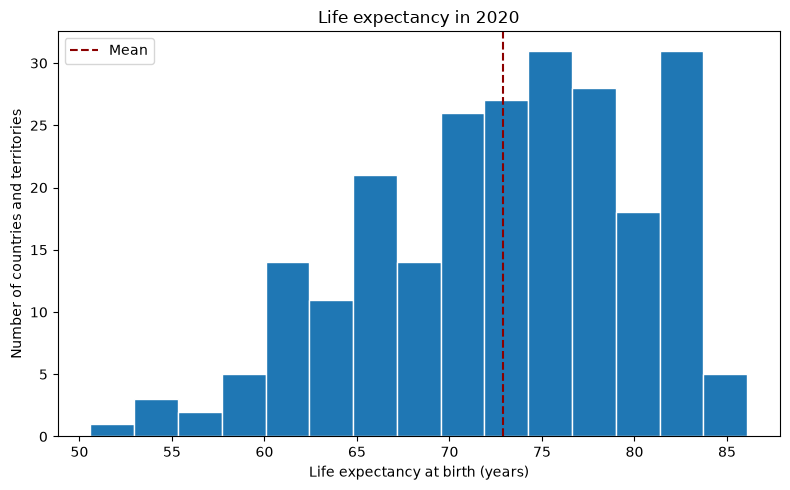

In [27]:
plt.figure(figsize=(8, 5))
plt.hist(df["life_expectancy"], bins=15, edgecolor="white")
plt.axvline(summary["mean"], color="darkred", linestyle="--", label="Mean")
plt.xlabel("Life expectancy at birth (years)")
plt.ylabel("Number of countries and territories")
plt.title("Life expectancy in 2020")
plt.legend()
plt.tight_layout()
plt.show()

## Findings

The cleaned data contains 237 countries and territories, after removing 24 aggregate rows. None of the retained rows had missing values or duplicates.

Mean life expectancy was **72.89 years**, the median was **73.83**, and the sample standard deviation was **7.32**. Values ranged from **50.60 years** in the Central African Republic to **86.09** in Monaco.

The mean is not population-weighted. This single-year comparison shows differences between places, but does not explain their causes or show changes over time.